# 📗 Laboratorio 2 – Miniproyectos con IA Aplicada a la Industria
**Curso:** IA Aplicada a la Industria  
**Profesora:** Myriam Vera Fuentes  
**Ayudante:** Pablo Macuada Rozas

---
En este laboratorio aplicarás técnicas básicas de análisis de datos e inteligencia artificial a situaciones reales en la industria:
- 🔧 Predicción de fallas en máquinas
- 📦 Clasificación de calidad de productos

## 🔧 Mini Proyecto 1 – Predicción de Falla en Máquinas

In [1]:
# Simulación de datos de sensores para una fábrica
import numpy as np  # Librería para trabajar con números y arreglos
import pandas as pd  # Librería para trabajar con tablas de datos

np.random.seed(42)  # Fijamos la semilla para que los resultados sean siempre iguales

# Creamos un DataFrame (tabla) con datos simulados de sensores
datos = pd.DataFrame({
    'temperatura': np.random.normal(70, 10, 500),  # Temperatura promedio 70, desviación 10
    'presion': np.random.normal(30, 5, 500),     # Presión promedio 30, desviación 5
    'vibracion': np.random.normal(5, 1, 500),    # Vibración promedio 5, desviación 1
    'falla': np.random.choice([0, 1], size=500, p=[0.8, 0.2])  # 0: sin falla, 1: con falla (20%)
})

# Mostramos las primeras filas de la tabla para ver los datos generados
datos.head()

,temperatura,presion,vibracion,falla
0,74.967142,34.630888,6.399355,0
1,68.617357,39.547083,5.924634,1
2,76.476885,23.007162,5.059630,0
3,85.230299,32.814846,4.353063,0
4,67.658466,26.746787,5.698223,0


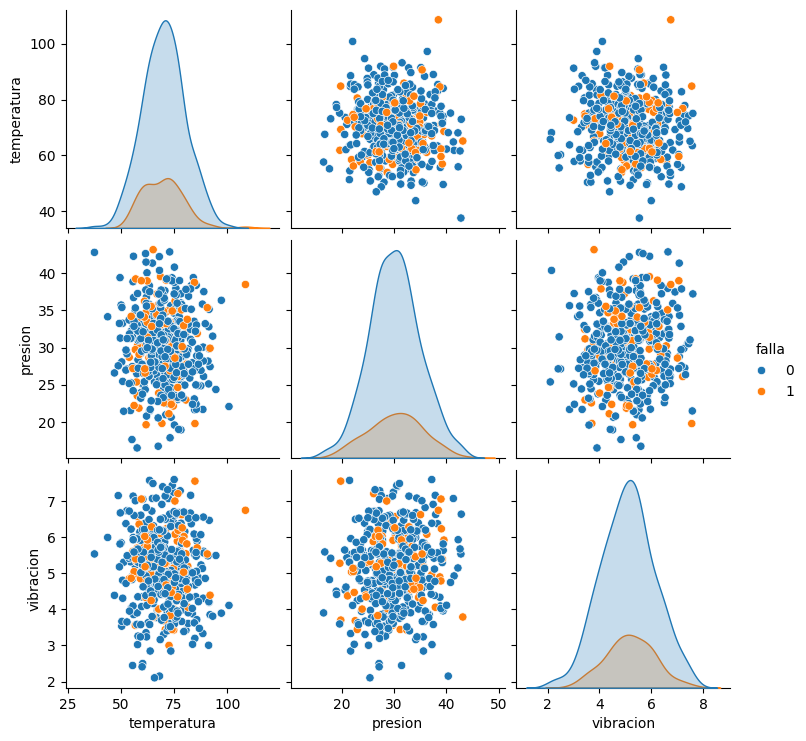

In [2]:
# Visualización de fallas en los datos simulados
import seaborn as sns  # Librería para gráficos estadísticos
import matplotlib.pyplot as plt  # Librería para gráficos

# Creamos un gráfico de pares para ver la relación entre variables y la presencia de fallas
sns.pairplot(datos, hue='falla');  # 'hue' colorea según si hubo falla o no

In [3]:
# Entrenamiento de un modelo de IA para predecir fallas en máquinas
from sklearn.model_selection import train_test_split  # Para separar datos en entrenamiento y prueba
from tensorflow.keras.models import Sequential  # Para crear modelos de redes neuronales
from tensorflow.keras.layers import Dense, Input  # Capas de la red neuronal
import numpy as np
import tensorflow as tf
import random

# Semillas para reproducibilidad (resultados iguales siempre)
np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

# Seleccionamos las variables de entrada (X) y la variable objetivo (y)
X = datos[['temperatura', 'presion', 'vibracion']]  # Variables de sensores
y = datos['falla']  # Variable que indica si hubo falla

# Dividimos los datos en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Definimos la arquitectura de la red neuronal
modelo = Sequential([
    Input(shape=(3,)),  # Capa de entrada con 3 variables
    Dense(10, activation='relu'),  # Capa oculta con 10 neuronas y activación ReLU
    Dense(6, activation='relu'),   # Otra capa oculta con 6 neuronas
    Dense(1, activation='sigmoid') # Capa de salida para clasificación binaria
])

# Compilamos el modelo (definimos cómo aprende)
modelo.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenamos el modelo con los datos de entrenamiento
historial = modelo.fit(X_train, y_train, epochs=25, validation_split=0.2, verbose=0)  # 25 ciclos de entrenamiento

# Evaluamos el modelo con los datos de prueba
precision_test = modelo.evaluate(X_test, y_test, verbose=0)  # Evaluación en datos de prueba
print(f"Precisión en datos de prueba: {precision_test[1]:.3f}")  # Mostramos la precisión

Precisión en datos de prueba: 0.750


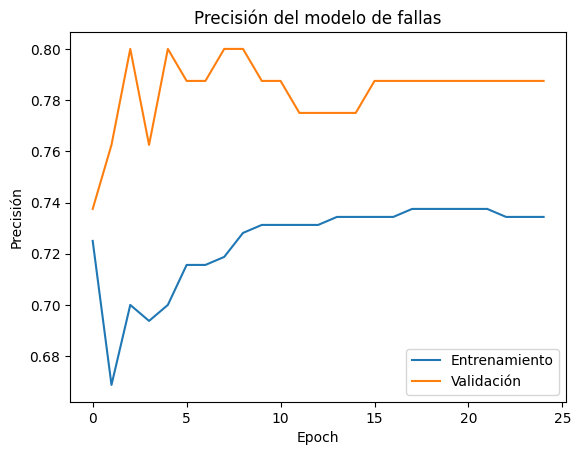

In [4]:
# Visualización de la precisión del modelo durante el entrenamiento
plt.plot(historial.history['accuracy'], label='Entrenamiento')  # Precisión en entrenamiento
plt.plot(historial.history['val_accuracy'], label='Validación')  # Precisión en validación
plt.title('Precisión del modelo de fallas')  # Título del gráfico
plt.xlabel('Epoch')  # Número de ciclo de entrenamiento
plt.ylabel('Precisión')  # Porcentaje de aciertos
plt.legend();  # Muestra la leyenda

## 📦 Mini Proyecto 2 – Clasificación de Calidad de Productos

In [5]:
# Simulación de datos para clasificación de calidad de productos
np.random.seed(0)  # Fijamos la semilla para reproducibilidad

# Creamos un DataFrame con variables de calidad
data = pd.DataFrame({
    'dureza': np.random.normal(50, 10, 600),  # Dureza promedio 50, desviación 10
    'peso': np.random.normal(200, 25, 600),  # Peso promedio 200, desviación 25
    'uniformidad': np.random.normal(0.8, 0.1, 600),  # Uniformidad promedio 0.8, desviación 0.1
})

# Función para asignar la calidad del producto según reglas simples
def asignar_calidad(row):
    if row['dureza'] > 55 and row['uniformidad'] > 0.85:
        return 'alta'  # Alta calidad
    elif row['dureza'] < 45 or row['uniformidad'] < 0.75:
        return 'baja'  # Baja calidad
    else:
        return 'media'  # Calidad media

# Aplicamos la función a cada fila de la tabla
data['calidad'] = data.apply(asignar_calidad, axis=1)

# Mostramos las primeras filas para ver los datos generados
data.head()

,dureza,peso,uniformidad,calidad
0,67.640523,161.239266,0.710363,baja
1,54.001572,210.432971,0.603727,baja
2,59.787380,176.390788,0.958482,alta
3,72.408932,205.952579,0.864797,alta
4,68.675580,164.850927,0.686099,baja


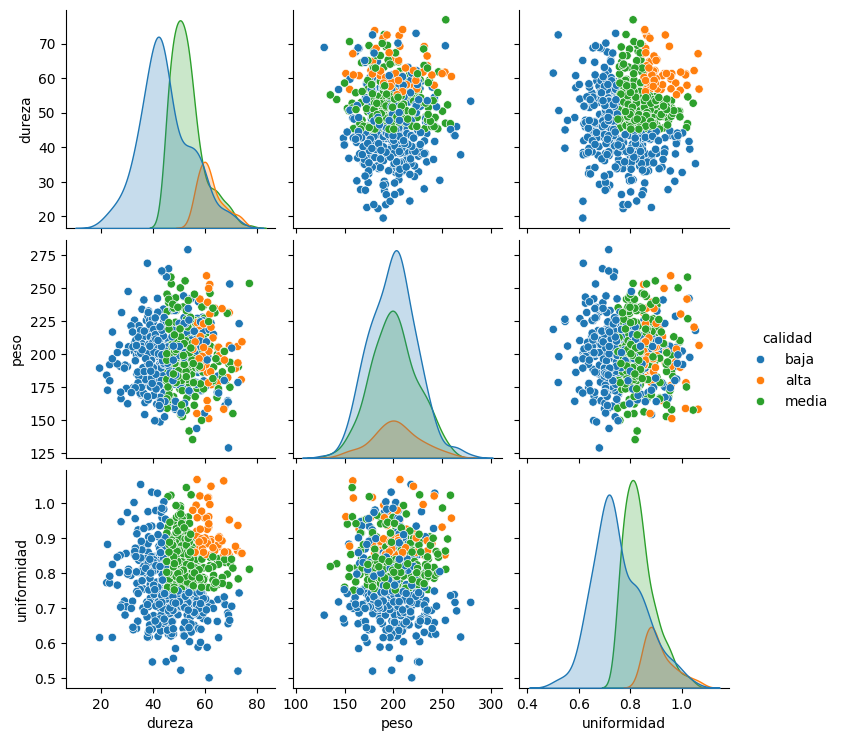

In [6]:
# Visualización de la calidad de los productos simulados
sns.pairplot(data, hue='calidad');  # Gráfico de pares coloreado según la calidad

In [7]:
# Modelo de clasificación multicategoría para predecir la calidad del producto
from sklearn.preprocessing import LabelEncoder  # Para convertir etiquetas a números
from tensorflow.keras.utils import to_categorical  # Para convertir etiquetas a formato categórico
from tensorflow.keras.layers import Input  # Capa de entrada para la red
import numpy as np
import tensorflow as tf
import random

# Semillas para reproducibilidad
np.random.seed(0)
tf.random.set_seed(0)
random.seed(0)

# Seleccionamos variables de entrada y la variable objetivo
X = data[['dureza', 'peso', 'uniformidad']]  # Variables de entrada
y = LabelEncoder().fit_transform(data['calidad'])  # Convertimos calidad a números
y_cat = to_categorical(y)  # Convertimos a formato categórico

# Dividimos los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.2, random_state=0)

# Definimos la arquitectura de la red neuronal
modelo2 = Sequential([
    Input(shape=(3,)),  # Capa de entrada con 3 variables
    Dense(12, activation='relu'),  # Capa oculta con 12 neuronas
    Dense(8, activation='relu'),   # Otra capa oculta con 8 neuronas
    Dense(3, activation='softmax') # Capa de salida para 3 clases
])

# Compilamos el modelo
modelo2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Entrenamos el modelo
historial2 = modelo2.fit(X_train, y_train, epochs=30, validation_split=0.2, verbose=0)  # 30 ciclos de entrenamiento

# Evaluamos el modelo con los datos de prueba  
precision_test2 = modelo2.evaluate(X_test, y_test, verbose=0)  # Evaluación en datos de prueba
print(f"Precisión en datos de prueba: {precision_test2[1]:.3f}")  # Mostramos la precisión

Precisión en datos de prueba: 0.642


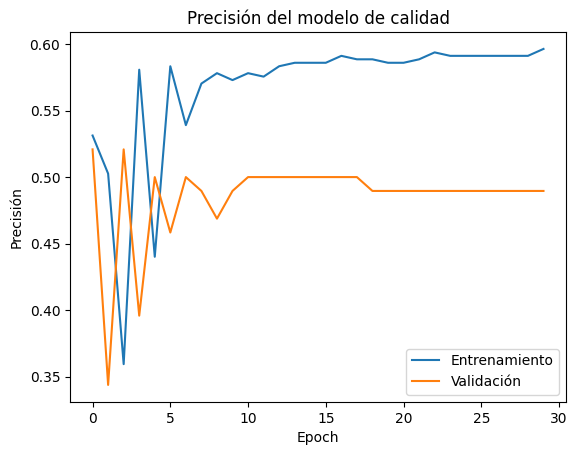

In [8]:
# Visualización de la precisión del modelo de calidad durante el entrenamiento
plt.plot(historial2.history['accuracy'], label='Entrenamiento')  # Precisión en entrenamiento
plt.plot(historial2.history['val_accuracy'], label='Validación')  # Precisión en validación
plt.title('Precisión del modelo de calidad')  # Título del gráfico
plt.xlabel('Epoch')  # Número de ciclo de entrenamiento
plt.ylabel('Precisión')  # Porcentaje de aciertos
plt.legend();  # Muestra la leyenda

## 📝 Tarea Final – Laboratorio 2 (Tipo Test)
Lee con atención y selecciona la **alternativa correcta** en cada caso:

**1. ¿Qué variable se relacionó más con la presencia de fallas en el Mini Proyecto 1?**
- A. Temperatura
- B. Peso
- C. Uniformidad
- D. Color del producto

**2. En el Mini Proyecto 2, ¿qué modelo se utilizó para clasificar la calidad de los productos?**
- A. Árbol de decisión
- B. Regresión lineal
- C. Red neuronal (Keras)
- D. Random Forest

**3. ¿Cuál es un uso real de este tipo de modelos en la industria?**
- A. Predecir el clima en la fábrica
- B. Detectar cuándo una máquina fallará antes de que ocurra
- C. Calcular los sueldos de los operarios
- D. Traducir etiquetas al inglés

✅ Marca las respuestas correctas escribiendo las letras seleccionadas abajo en un cuadro de markdown:

1.
2.
3.